# Empirics: Random Forest with Dow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import yfinance  as yf # data download

In [ ]:
data_raw = yf.download('^DJI', start='2010-1-1')

[*********************100%%**********************]  1 of 1 completed


In [ ]:
data_raw.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,10430.690430,10604.969727,10430.690430,10583.959961,10583.959961,179780000
2010-01-05,10584.559570,10584.559570,10522.519531,10572.019531,10572.019531,188540000
2010-01-06,10564.719727,10594.990234,10546.549805,10573.679688,10573.679688,186040000
2010-01-07,10571.110352,10612.370117,10505.209961,10606.860352,10606.860352,217390000
2010-01-08,10606.400391,10619.400391,10554.330078,10618.190430,10618.190430,172710000


In [ ]:
ret = df.Close.pct_change()  ** 2

In [ ]:
data_raw["Close"].pct_change()

Date
2010-01-04         NaN
2010-01-05   -0.001128
2010-01-06    0.000157
2010-01-07    0.003138
2010-01-08    0.001068
                ...   
2023-10-11    0.001943
2023-10-12   -0.005139
2023-10-13    0.001164
2023-10-16    0.009333
2023-10-17    0.000386
Name: Close, Length: 3471, dtype: float64

<Axes: xlabel='Date'>

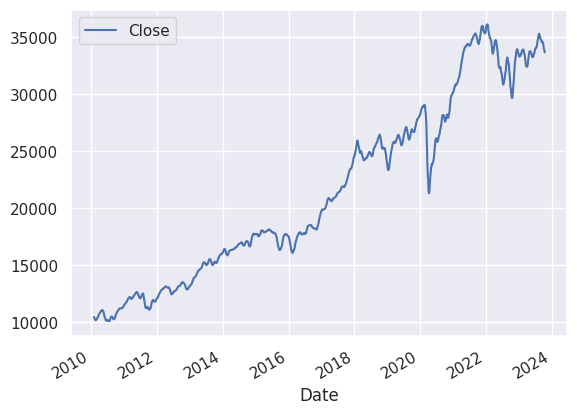

In [ ]:
data_raw[["Close"]].rolling(20).mean().plot()

# Question? OHLC?
##  1. 과거 pandas
##  2. plotly / bokeh

Text(0.5, 1.0, 'Dow over the last  decade')

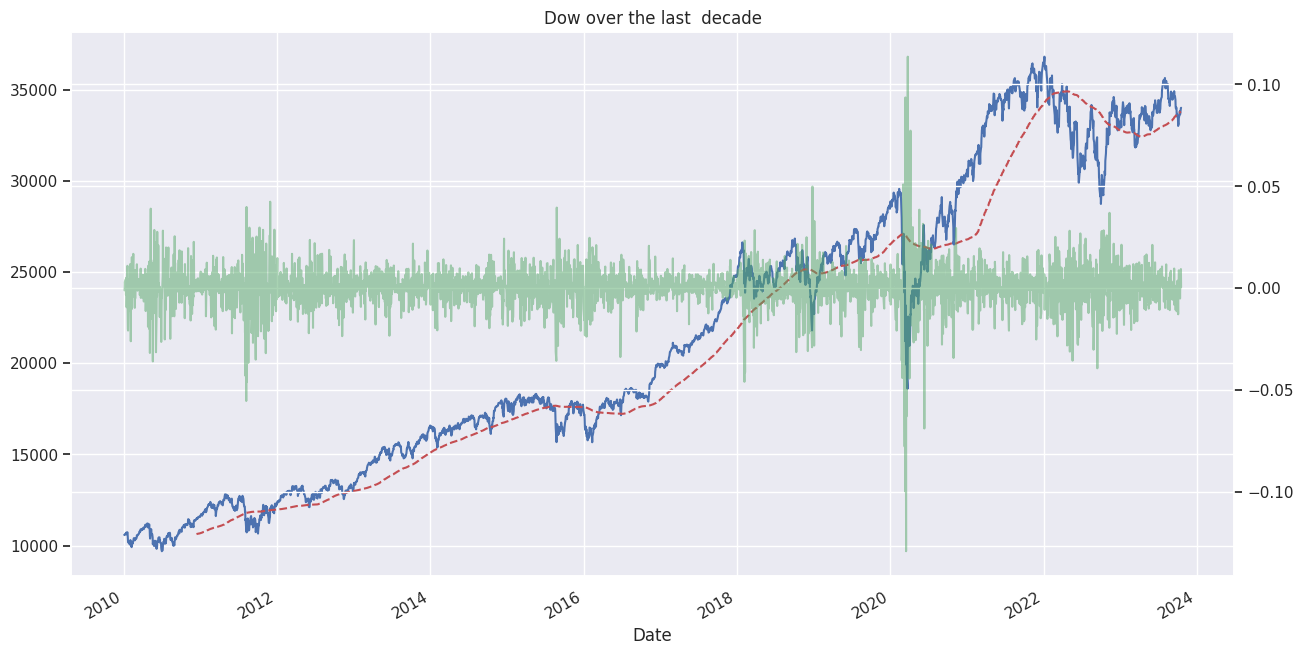

In [ ]:
plt.figure(figsize=(15,8))
ax=data_raw['Close'].plot()
data_raw.Close.rolling(240).mean().plot(ax=ax, c='r', ls="--")
ax2 = ax.twinx()
data_raw["Close"].pct_change().dropna().plot(ax=ax2, c='g', alpha=0.5)
plt.title("Dow over the last  decade")


# ret**2 shows VOLATILITY CLUSTERING

Text(0.5, 1.0, 'Dow over the last  decade')

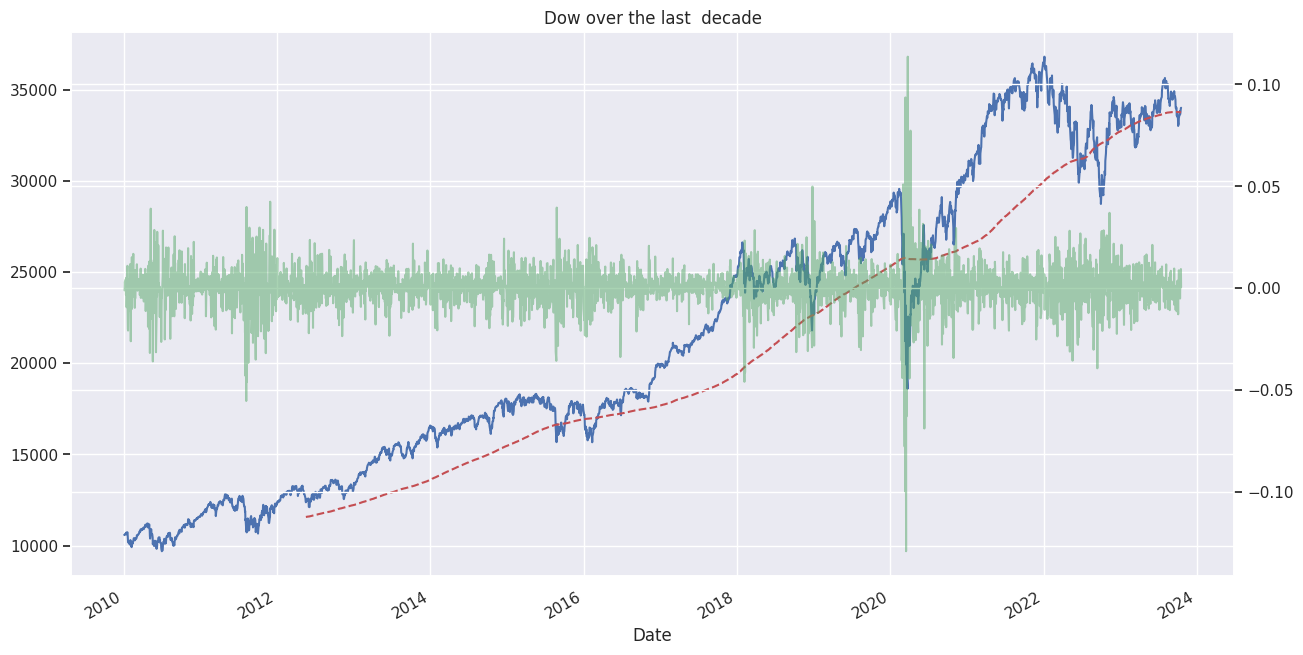

In [ ]:
plt.figure(figsize=(15,8))
ax=data_raw['Close'].plot()
data_raw.Close.rolling(600).mean().plot(ax=ax, c='r', ls="--")
ax2 = ax.twinx()
data_raw["Close"].pct_change().dropna().plot(ax=ax2, c='g', alpha=0.5)
plt.title("Dow over the last  decade")

In [ ]:
X_raw = generate_features2(data_raw)

In [ ]:
X_raw.iloc[:, 2:].corrwith(X_raw['Ret'])

moving_avg_5               0.424834
moving_avg_20              0.212662
moving_avg_240             0.071232
ratio_avg_price_5_30       0.047105
ratio_avg_price_5_365     -0.020980
ratio_avg_price_30_365    -0.039975
ratio_std_price_5_30      -0.045275
ratio_std_price_5_365     -0.095924
ratio_std_price_30_365    -0.026031
ratio_std_volume_5_30     -0.043945
ratio_std_volume_5_365    -0.051421
ratio_std_volume_30_365   -0.021587
dtype: float64

In [ ]:
y = np.sign(X_raw['Ret'])
X = X_raw.iloc[:,2: ]

In [ ]:
X

,moving_avg_5,moving_avg_20,moving_avg_240,ratio_avg_price_5_30,ratio_avg_price_5_365,ratio_avg_price_30_365,ratio_std_price_5_30,ratio_std_price_5_365,ratio_std_price_30_365,ratio_std_volume_5_30,ratio_std_volume_5_365,ratio_std_volume_30_365
Date,,,,,,,,,,,,
2011-01-04,0.002000,0.001256,0.000439,1.009214,1.086470,1.076551,0.464301,0.091147,0.196311,0.864396,0.840755,0.972651
2011-01-05,0.001995,0.001431,0.000451,1.009933,1.088184,1.077482,0.588369,0.122531,0.208256,0.982794,0.962655,0.979508
2011-01-06,0.002368,0.001580,0.000461,1.010814,1.090294,1.078630,0.671768,0.146051,0.217412,0.910394,0.890685,0.978351
2011-01-07,0.002202,0.001412,0.000440,1.011615,1.092241,1.079700,0.545823,0.117297,0.214900,0.703430,0.693866,0.986404
2011-01-10,0.001681,0.001327,0.000428,1.012038,1.093632,1.080623,0.209395,0.043222,0.206414,0.206996,0.206214,0.996225
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-11,0.004431,-0.001306,0.000597,0.984908,0.994824,1.010068,0.477423,0.251134,0.526021,0.547355,0.520843,0.951565
2023-10-12,0.004049,-0.001107,0.000618,0.990060,0.998304,1.008326,0.498020,0.259084,0.520227,0.548024,0.523924,0.956024
2023-10-13,0.003081,-0.001844,0.000592,0.994401,1.000831,1.006466,0.283786,0.146747,0.517106,0.560330,0.535754,0.956140


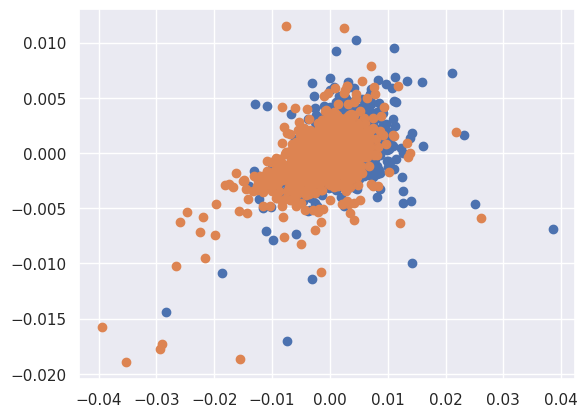

In [ ]:
plt.scatter(X['moving_avg_5'][y==1], X['moving_avg_20'][y==1])
plt.scatter(X['moving_avg_5'][y==-1], X['moving_avg_20'][y==-1])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
# data splitting
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y)

# you may divide samples with your own cutting point
## Xtrain = X[:cutting_point, :]  # numpy
#  Xtrain = X[:"2018-01-01"]   # pd dataframe

In [ ]:
# generate instances

clf_rf = RandomForestClassifier()  # instantiation
clf_rf.fit(Xtrain, ytrain )   # fitting

RandomForestClassifier()

In [ ]:
ytest
#clf_rf.predict(Xtest)

Date
2022-07-07    1.0
2022-11-09    1.0
2021-04-28    1.0
2011-10-19    1.0
2020-07-22    1.0
             ... 
2014-03-05    1.0
2012-10-31    1.0
2021-06-09   -1.0
2011-06-07   -1.0
2012-02-15    1.0
Name: Ret, Length: 805, dtype: float64

In [ ]:
# evaluate accuracy

from sklearn.metrics import accuracy_score

accuracy_score(ytest, clf_rf.predict(Xtest))

0.6037267080745342

Text(0.5, 1.0, 'Feature Importance')

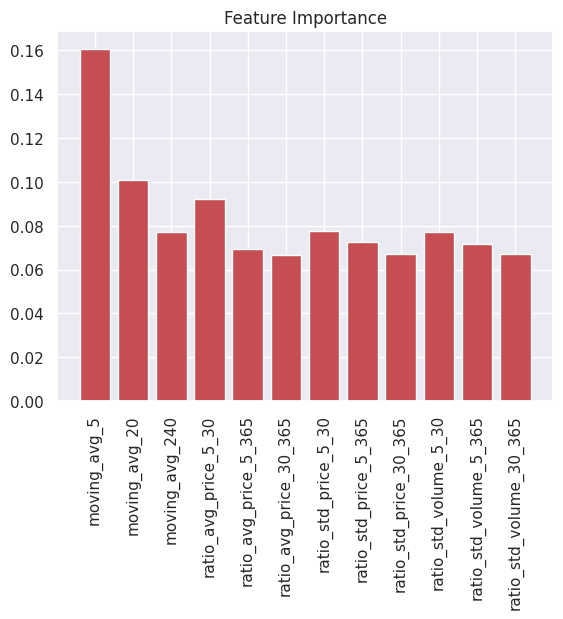

In [ ]:
# plot feature importance

feature_imp = clf_rf.feature_importances_

plt.bar(range(len(feature_imp)), feature_imp, color='r')
plt.xticks(range(len(feature_imp)), Xtrain.columns, rotation='vertical')
plt.title('Feature Importance')

In [ ]:
# is it reasonable?
# to grasp the idea of linear regression analyze correlation

x_corr = X_raw.iloc[:, 2:].corrwith(X_raw['Ret'])
x_corr.sort_values(axis=0,  ascending=False)

moving_avg_5               0.424834
moving_avg_20              0.212662
moving_avg_240             0.071232
ratio_avg_price_5_30       0.047105
ratio_avg_price_5_365     -0.020980
ratio_std_volume_30_365   -0.021587
ratio_std_price_30_365    -0.026031
ratio_avg_price_30_365    -0.039975
ratio_std_volume_5_30     -0.043945
ratio_std_price_5_30      -0.045275
ratio_std_volume_5_365    -0.051421
ratio_std_price_5_365     -0.095924
dtype: float64

In [ ]:
# accumulate feature

feature_imp_seris = pd.Series(feature_imp, index=Xtrain.columns)
feature_imp_seris.sort_values(axis=0, ascending=False, inplace=True)
feature_imp_seris

moving_avg_5               0.160630
moving_avg_20              0.100927
ratio_avg_price_5_30       0.092395
ratio_std_price_5_30       0.077546
moving_avg_240             0.076993
ratio_std_volume_5_30      0.076957
ratio_std_price_5_365      0.072751
ratio_std_volume_5_365     0.071624
ratio_avg_price_5_365      0.069175
ratio_std_price_30_365     0.067310
ratio_std_volume_30_365    0.067262
ratio_avg_price_30_365     0.066430
dtype: float64

Text(0.5, 1.0, 'Feature accumulation')

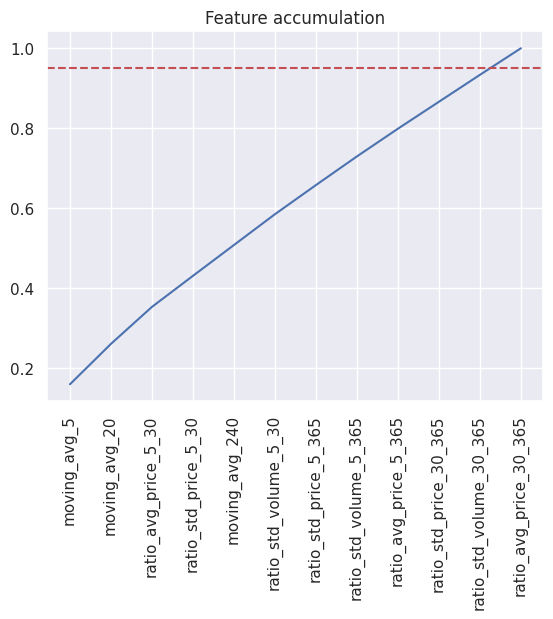

In [ ]:
plt.plot(range(len(feature_imp_seris)), feature_imp_seris.values.cumsum())
plt.axhline(0.95, color='r', linestyle='dashed')
plt.xticks(range(len(feature_imp_seris)), feature_imp_seris.index, rotation='vertical')
plt.title('Feature accumulation')

###  data structure

- pandas dataframe:

```python
df=pd.DataFrame()
df['close']=data_raw.Close
df['ma5'] = df.close.rolling(5).mean()
df = df.assign(ma20=df.close.rolling(20).mean())
df['vol'] = (df.close.pct_change().dropna())**2
```

In [ ]:
def generate_features2(df):
    """ Generate features for a stock/index based on historical price and performance
    Args:
        df (dataframe with columns "Open", "Close", "High", "Low", "Volume", "Adjusted Close")
    Returns:
        dataframe, data set with new features
    """
    df_new = pd.DataFrame()

    # the target
    df_new['Close'] = df['Close']

    # basics: return
    df_new['Ret'] = ((df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)).shift(1)
    return_5 = ((df['Close'] - df['Close'].shift(5)) / df['Close'].shift(5)).shift(1)
    return_30 = ((df['Close'] - df['Close'].shift(21)) / df['Close'].shift(21)).shift(1)
    return_365 = ((df['Close'] - df['Close'].shift(252)) / df['Close'].shift(252)).shift(1)
    df_new['moving_avg_5'] = df_new['Ret'].rolling(5).mean()
    df_new['moving_avg_20'] = df_new['Ret'].rolling(20).mean()
    df_new['moving_avg_240'] = df_new['Ret'].rolling(252).mean()


    # average price
    avg_price_5  = df['Close'].rolling(5).mean().shift(1)
    avg_price_30 = df['Close'].rolling(21).mean().shift(1)
    avg_price_365= df['Close'].rolling(252).mean().shift(1)
    df_new['ratio_avg_price_5_30'] = avg_price_5 / avg_price_30
    df_new['ratio_avg_price_5_365'] = avg_price_5 / avg_price_365
    df_new['ratio_avg_price_30_365'] = avg_price_30 / avg_price_365

    # average volume
    avg_volume_5 = df['Volume'].rolling(5).mean().shift(1)
    avg_volume_30 = df['Volume'].rolling(21).mean().shift(1)
    avg_volume_365 = df['Volume'].rolling(252).mean().shift(1)
    ratio_avg_volume_5_30 = avg_volume_5 / avg_volume_30
    ratio_avg_volume_5_365 = avg_volume_5 / avg_volume_365
    ratio_avg_volume_30_365 = avg_volume_30 / avg_volume_365

    # standard deviation of prices
    std_price_5 = df['Close'].rolling(5).std().shift(1)
    std_price_30 = df['Close'].rolling(21).std().shift(1)
    std_price_365 = df['Close'].rolling(252).std().shift(1)
    df_new['ratio_std_price_5_30'] = std_price_5 / std_price_30
    df_new['ratio_std_price_5_365'] = std_price_5 / std_price_365
    df_new['ratio_std_price_30_365'] = std_price_30 / std_price_365

    # standard deviation of volumes
    std_volume_5 = df['Volume'].rolling(5).std().shift(1)
    std_volume_30 = df['Volume'].rolling(21).std().shift(1)
    std_volume_365 = df['Volume'].rolling(252).std().shift(1)
    df_new['ratio_std_volume_5_30'] = std_volume_5 / std_volume_30
    df_new['ratio_std_volume_5_365'] = std_volume_5 / std_volume_365
    df_new['ratio_std_volume_30_365'] = std_volume_30 / std_volume_365


    df_new = df_new.dropna(axis=0)
    return df_new